In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

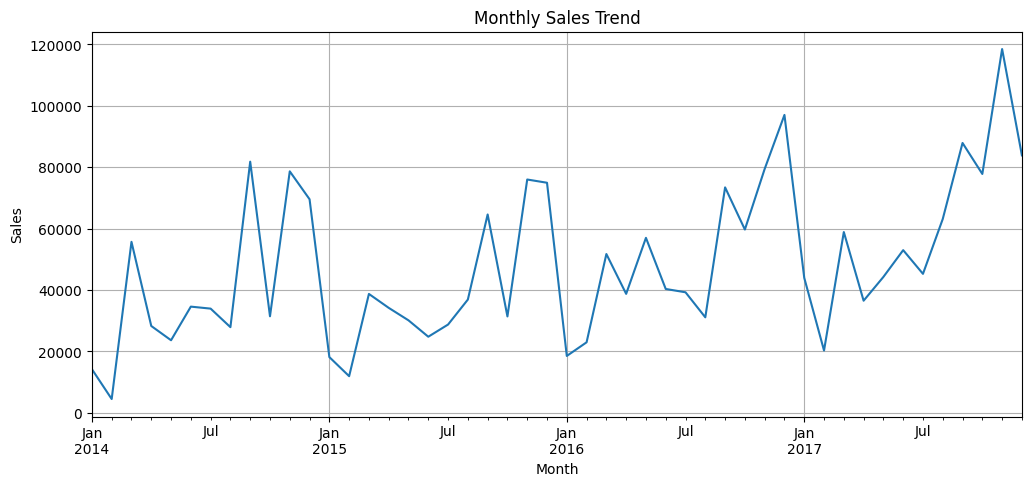

In [10]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [11]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


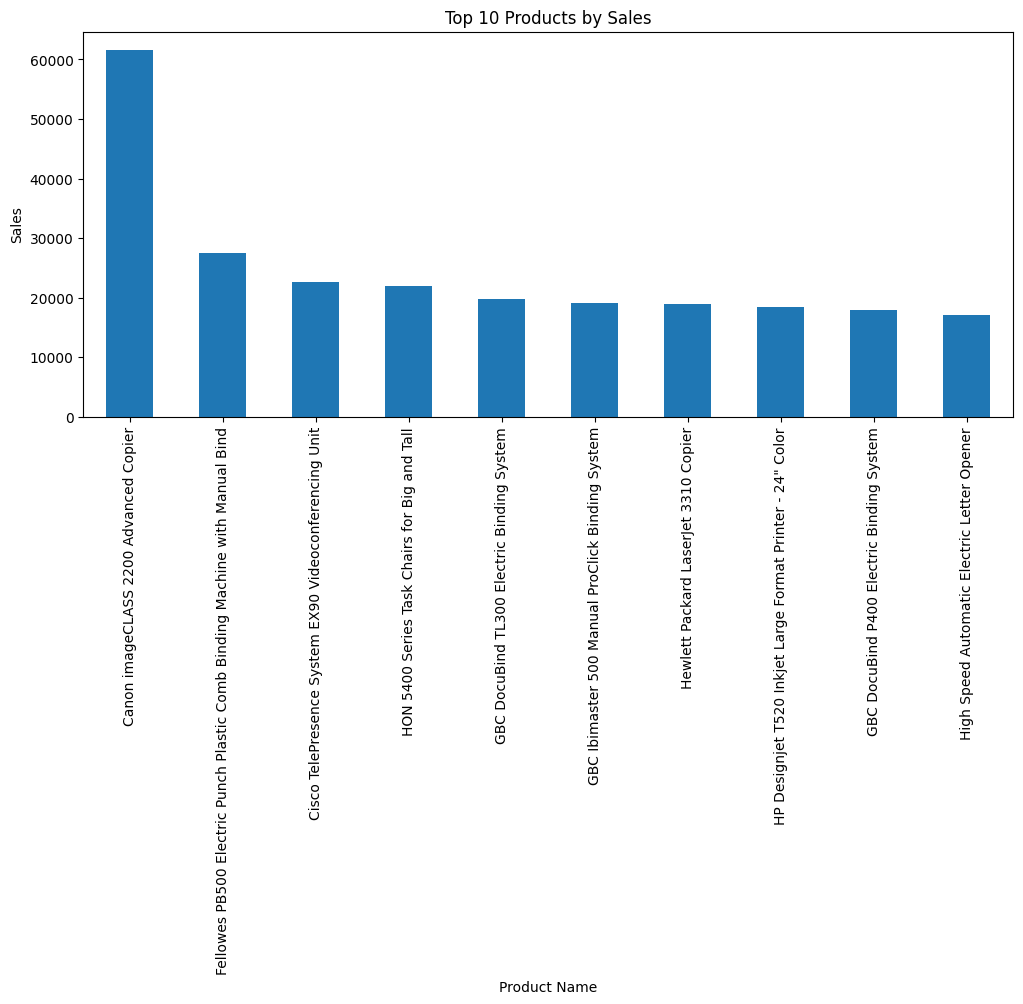

In [12]:
top_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

In [13]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


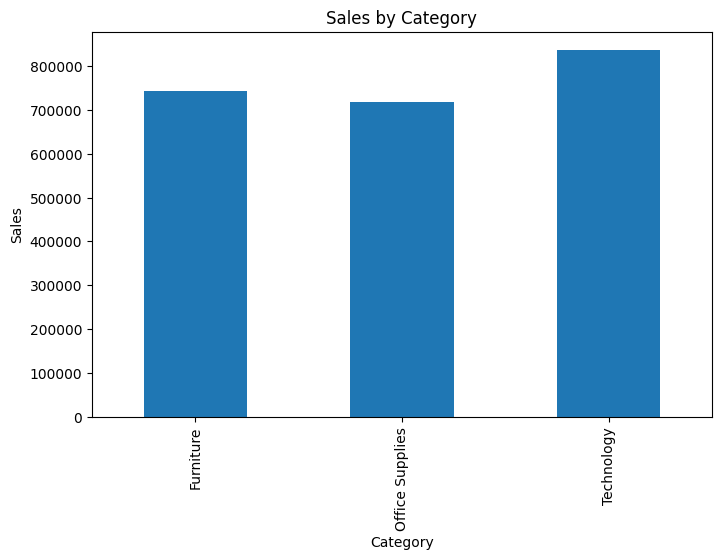

In [14]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [15]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


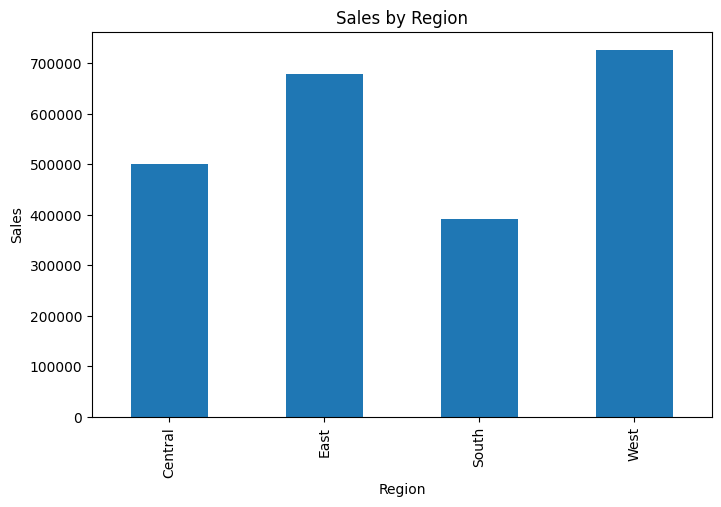

In [16]:
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

In [17]:
region_profit = df.groupby('Region')['Profit'].sum()

print(region_profit)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


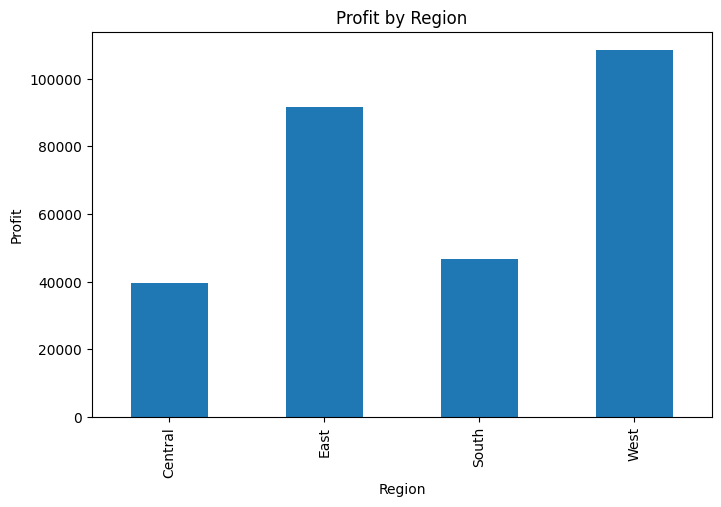

In [18]:
region_profit.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

In [19]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


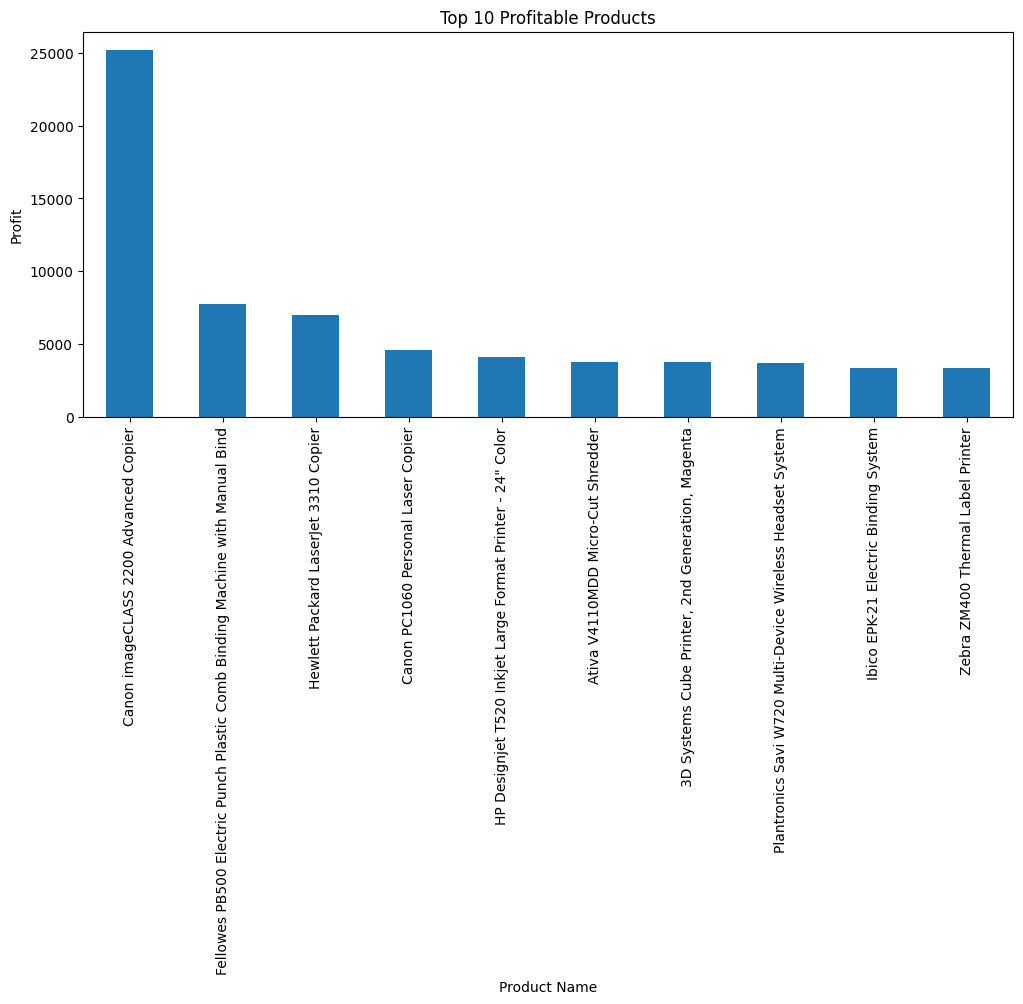

In [20]:
top_profit_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Profitable Products")
plt.ylabel("Profit")
plt.show()

In [21]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


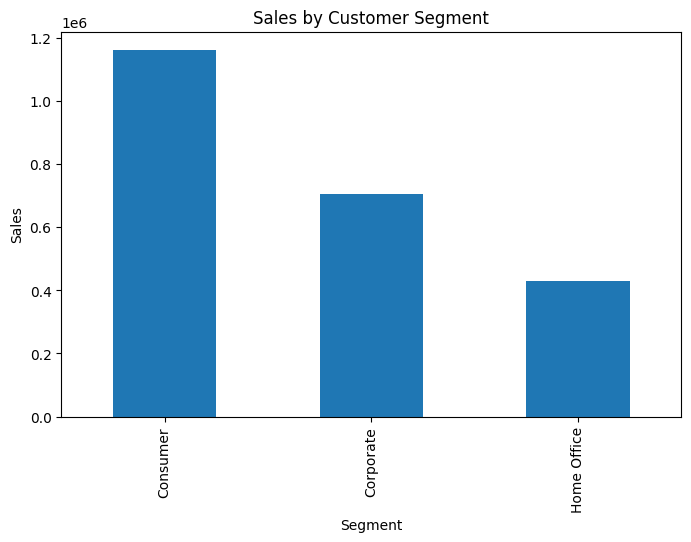

In [22]:
segment_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Customer Segment")
plt.ylabel("Sales")
plt.show()